<a href="https://colab.research.google.com/github/polokocodes/Spam-detection-exam/blob/main/Spam_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#STEP 1: PROBLEM FRAMING

Build a Spam detection Web app where:
Users inputs a message
Model predicts spam or not spam

This system can be used by individuals who recieve multiple text messages. The system will help people respond only to important messages. The system will recieve the message first and decide whether it is spam or not spam. All spam messages will be filtered out leaving behind the important messages

In [71]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 62.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 81.6 MB/s eta 0:00:00


In [72]:
# Module uploads
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import streamlit as st

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.feature_extraction.text import TfidfVectorizer

In [55]:
spam_data = pd.read_csv('/content/spam_dataset_train.csv')

#Data preprocessing
def preprocessing(spam_data):
  print("\n The data's shape is \n",spam_data.shape)
  print("\n Datatype \n", spam_data.dtypes)
  print("\n Missing values \n", spam_data.isnull().sum())
  print("\n Spam data info\n ", spam_data.info )

  return spam_data

preprocessing(spam_data)


 The data's shape is 
 (4457, 4)

 Datatype 
 Unnamed: 0           int64
Category             int64
Message             object
Embedded_Message    object
dtype: object

 Missing values 
 Unnamed: 0          0
Category            0
Message             0
Embedded_Message    0
dtype: int64

 Spam data info
  <bound method DataFrame.info of       Unnamed: 0  Category                                            Message  \
0              0         0  Yeah like if it goes like it did with my frien...   
1              1         0    Yeah confirmed for you staying at  that weekend   
2              2         0  One day a crab was running on the sea shore..T...   
3              3         0  The sign of maturity is not when we start sayi...   
4              4         0  Its a big difference.  &lt;#&gt;  versus  &lt;...   
...          ...       ...                                                ...   
4452        4452         1  Get ur 1st RINGTONE FREE NOW! Reply to this ms...   
4453        

,Unnamed: 0,Category,Message,Embedded_Message
0,0,0,Yeah like if it goes like it did with my frien...,[-1.45205408e-01 2.13783961e-02 1.41234808e-...
1,1,0,Yeah confirmed for you staying at that weekend,[-1.80612266e-01 8.22720677e-02 -5.74405631e-...
2,2,0,One day a crab was running on the sea shore..T...,[-1.35232225e-01 4.55702581e-02 6.93703070e-...
3,3,0,The sign of maturity is not when we start sayi...,[-1.24188282e-01 1.44440867e-02 -8.25601444e-...
4,4,0,Its a big difference. &lt;#&gt; versus &lt;...,[-1.35210305e-01 9.32803901e-04 4.62825736e-...
...,...,...,...,...
4452,4452,1,Get ur 1st RINGTONE FREE NOW! Reply to this ms...,[-1.15395829e-01 3.34329717e-02 2.23762430e-...
4453,4453,0,Where at were hungry too,[-1.79376170e-01 6.91064168e-03 1.39076577e-...
4454,4454,0,Yar lor actually we quite fast... Cos da ge sl...,[-1.46977887e-01 1.04964217e-02 1.51862334e-...
4455,4455,0,… and don‘t worry we‘ll have finished by march...,[-1.49874806e-01 1.93881765e-02 -1.54959410e-...


In [19]:
spam_data.head()

,Unnamed: 0,Category,Message,Embedded_Message
0,0,0,Yeah like if it goes like it did with my frien...,[-1.45205408e-01 2.13783961e-02 1.41234808e-...
1,1,0,Yeah confirmed for you staying at that weekend,[-1.80612266e-01 8.22720677e-02 -5.74405631e-...
2,2,0,One day a crab was running on the sea shore..T...,[-1.35232225e-01 4.55702581e-02 6.93703070e-...
3,3,0,The sign of maturity is not when we start sayi...,[-1.24188282e-01 1.44440867e-02 -8.25601444e-...
4,4,0,Its a big difference. &lt;#&gt; versus &lt;...,[-1.35210305e-01 9.32803901e-04 4.62825736e-...


In [20]:
spam_data.describe()

,Unnamed: 0,Category
count,4457.000000,4457.000000
mean,2228.000000,0.135293
std,1286.769404,0.342074
min,0.000000,0.000000
25%,1114.000000,0.000000
50%,2228.000000,0.000000
75%,3342.000000,0.000000
max,4456.000000,1.000000


In [37]:
spam_data.columns


Index(['Unnamed: 0', 'Category', 'Message', 'Embedded_Message'], dtype='object')

In [38]:
spam_data['Category'].value_counts()

,count
Category,
0,3854
1,603


In [58]:
spam_data['Category_map'] = spam_data['Category'].map({1:'spam' , 0:'nt_spam'})
spam_data.head()

,Unnamed: 0,Category,Message,Embedded_Message,Category_count,Category_map
0,0,0,Yeah like if it goes like it did with my frien...,[-1.45205408e-01 2.13783961e-02 1.41234808e-...,3854.0,nt_spam
1,1,0,Yeah confirmed for you staying at that weekend,[-1.80612266e-01 8.22720677e-02 -5.74405631e-...,603.0,nt_spam
2,2,0,One day a crab was running on the sea shore..T...,[-1.35232225e-01 4.55702581e-02 6.93703070e-...,NaN,nt_spam
3,3,0,The sign of maturity is not when we start sayi...,[-1.24188282e-01 1.44440867e-02 -8.25601444e-...,NaN,nt_spam
4,4,0,Its a big difference. &lt;#&gt; versus &lt;...,[-1.35210305e-01 9.32803901e-04 4.62825736e-...,NaN,nt_spam


In [61]:
spam_data['Category_count'] = spam_data.value_counts('Category')
spam_data.head()

,Unnamed: 0,Category,Message,Embedded_Message,Category_count,Category_map
0,0,0,Yeah like if it goes like it did with my frien...,[-1.45205408e-01 2.13783961e-02 1.41234808e-...,3854.0,nt_spam
1,1,0,Yeah confirmed for you staying at that weekend,[-1.80612266e-01 8.22720677e-02 -5.74405631e-...,603.0,nt_spam
2,2,0,One day a crab was running on the sea shore..T...,[-1.35232225e-01 4.55702581e-02 6.93703070e-...,NaN,nt_spam
3,3,0,The sign of maturity is not when we start sayi...,[-1.24188282e-01 1.44440867e-02 -8.25601444e-...,NaN,nt_spam
4,4,0,Its a big difference. &lt;#&gt; versus &lt;...,[-1.35210305e-01 9.32803901e-04 4.62825736e-...,NaN,nt_spam


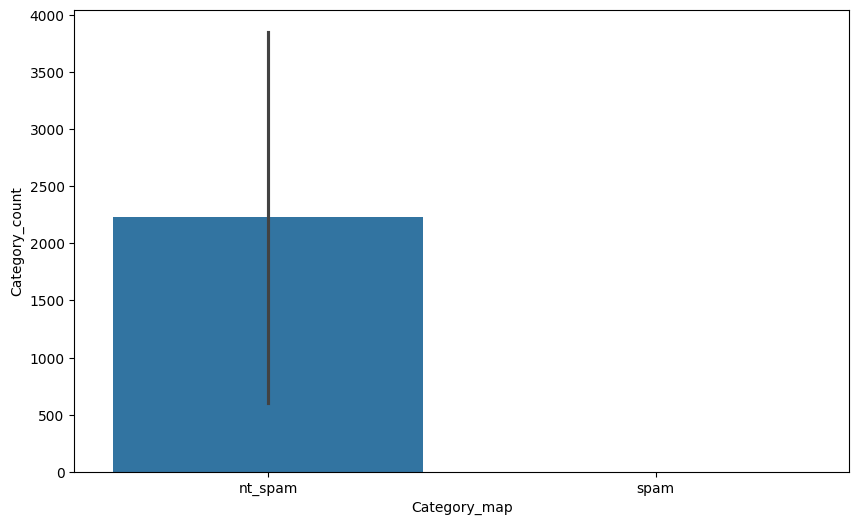

In [69]:
plt.figure(figsize=(10,6))
sns.barplot(data = spam_data, x = 'Category_map', y = 'Category_count')
plt.show()

The data is imbalanced as it contains more not spam than spam

In [65]:
y = spam_data['Category_map']

In [66]:
vectorizer = TfidfVectorizer()
x = vectorizer.fit_transform(spam_data['Message'])


In [68]:
x_train, x_test, y_train, y_test = train_test_split(x,y)

model = LogisticRegression()
model.fit(x_train, y_train)
prediction = model.predict(x_test)
print(accuracy_score(y_test, prediction))


0.9632286995515695


I chose logistics regression because the problem is a classification type problem which deals with classifying text messages as spam or not spam. Logistic Regression works best on such problems. The accuracy of the model is 96% which might suggest that there is overfitting.  

#PRODUCT THINKING
This product can be used by both individuals and businesses to filter thier messages. More data should be collected to increase the amount of not spam data to balance the data and some of the limitation are also as mentioned lack of enough data. The model also memorised the data.